# ⚽ Football Analytics with Python
## Chapter 7 — Radar Charts

**BarcaFutbol Analytics Course · HackrLife Media LLC**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HackrLife/Football-Analytics/blob/main/The-Football-Analytics-Course/Chapter-07-Radar-Charts/Chapter_07_Radar_Charts.ipynb)

---

The radar chart — also called a spider chart — is the signature visualisation
of football analytics. Open any scouting report, any analytics newsletter, any
StatsBomb graphic and you will see radars. They are everywhere because they do
something no other chart can: show a player's complete multi-dimensional profile
in a single glance.

But most radars you see online are built incorrectly. They use raw stats instead
of percentile ranks. They do not close the polygon. They have no outer boundary ring.
They look amateurish because they skipped the geometry.

This chapter teaches radars from first principles — the polar coordinate system,
closing the polygon, the outer boundary ring, vertex markers, and the dual-radar
for comparing two players on the same axes.

### What You Will Build

1. **A single player radar** — 6 metrics, one player
2. **A dual-player radar** — two players on the same axes
3. **The `build_radar()` template** — any 6 metrics, any two players

### The Key Concept: Polar Coordinates

A radar chart is drawn on **polar axes**. Instead of X and Y, polar coordinates
use **angle** (where around the circle) and **radius** (how far from the centre).

Each metric gets an angle. The metric's value determines the radius.
Connect the dots and you have a radar.

```python
fig, ax = plt.subplots(subplot_kw=dict(polar=True))
```

That one argument — `polar=True` — is all that separates a radar from a line chart.

---
*Course GitHub: [github.com/HackrLife/Football-Analytics](https://github.com/HackrLife/Football-Analytics)*

In [1]:
!pip install pandas matplotlib numpy scipy --quiet
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge, Circle
from matplotlib.lines import Line2D
from scipy.interpolate import make_interp_spline
%matplotlib inline
plt.rcParams['figure.dpi'] = 150
print("✓ Ready.")

✓ Ready.


In [1]:
BG='#0d1117'; BG2='#0d1b2a'; BG3='#161b22'
WHITE='#f0f6fc'; GRAY='#8b949e'; GOLD='#EDBB00'
GREEN='#4CAF50'; YELLOW='#ffd60a'; ORANGE='#FF9800'; RED='#e63946'
TIER_COLORS={'Elite':GREEN,'Above Average':YELLOW,'Average':ORANGE,'Below Average':RED}
PLAYER_COLORS={
    'Marcus Silva':'#3498DB','Lucas Ferreira':'#2ecc71',
    'James Thornton':'#e74c3c','Diego Varela':'#9B59B6',
    'Amir Hassan':'#FF9800','Kai Becker':'#00BCD4',
    'Tom Wheeler':'#F06292','Sam Okafor':'#80CBC4',
    'Elena Rossi':'#FFD54F','Carlos Mendez':'#CE93D8',
    'Jin Park':'#A5D6A7',
}
def style_axis(ax,theme='dark',xlabel=None,ylabel=None,title=None,subtitle=None):
    bg=BG if theme=='dark' else '#f8f9fa'
    tc=WHITE if theme=='dark' else '#1a1a2e'
    gc=WHITE if theme=='dark' else '#cccccc'
    sc=GRAY  if theme=='dark' else '#888888'
    ax.set_facecolor(bg)
    ax.spines['bottom'].set_color(sc); ax.spines['left'].set_color(sc)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(colors=tc,labelsize=10)
    ax.grid(True,alpha=0.07,color=gc,linewidth=0.8)
    if xlabel: ax.set_xlabel(xlabel,color=tc,fontsize=11,labelpad=8)
    if ylabel: ax.set_ylabel(ylabel,color=tc,fontsize=11,labelpad=8)
    if title and subtitle:
        ax.set_title(title+'\n'+subtitle,color=tc,fontsize=13,fontweight='bold',pad=15,linespacing=1.6)
    elif title: ax.set_title(title,color=tc,fontsize=13,fontweight='bold',pad=12)
    return ax
print("✓ Design system loaded.")

✓ Design system loaded.


In [1]:
df = pd.read_csv('data/chapter07_players.csv')
print(df[['player','goals_per90','assists_per90','shots_per90','pass_accuracy_pct','dribbles_per90','tackles_per90']].to_string(index=False))

        player  goals_per90  assists_per90  shots_per90  pass_accuracy_pct  dribbles_per90  tackles_per90
  Marcus Silva         0.54           0.33         3.45               79.1            3.86           1.19
Lucas Ferreira         0.31           0.44         2.59               84.7            2.44           1.58
James Thornton         0.48           0.31         3.22               77.2            6.07           1.28
  Diego Varela         0.48           0.22         4.44               75.8            3.89           1.81
   Amir Hassan         0.34           0.43         2.51               86.4            2.00           1.91
    Kai Becker         0.35           0.29         3.01               81.3            4.39           1.52
   Tom Wheeler         0.31           0.45         2.93               82.6            3.21           1.92
    Sam Okafor         0.12           0.32         3.16               80.4            2.96           1.93
   Elena Rossi         0.29           0.23    

---
## Part 1 — Understanding Polar Coordinates

Before writing the radar, understand the geometry.

A standard chart uses x (horizontal) and y (vertical). A polar chart uses:
- **θ (theta)** — the angle, measured in radians from 0 to 2π
- **r (radius)** — the distance from the centre

For a 6-metric radar, we divide 360° (2π radians) equally into 6 slices:
`2π ÷ 6 = 1.047 radians per slice (60° each)`

`np.linspace(0, 2*np.pi, 6, endpoint=False)` gives us those 6 angles.

**The most common mistake:** not closing the polygon. The last point must
connect back to the first. We do this by appending `angles[:1]` and `values[:1]`
to their respective lists.

In [1]:
# Part 1 — Visualise the geometry before drawing the chart
import numpy as np

n_metrics = 6
angles = np.linspace(0, 2*np.pi, n_metrics, endpoint=False).tolist()

print("6 metric angles (radians):")
for i, a in enumerate(angles):
    print(f"  Metric {i+1}: {a:.3f} radians = {np.degrees(a):.1f}°")

print()
print("Closing the polygon:")
print(f"  Original angles: {len(angles)} points")
angles_closed = angles + angles[:1]
print(f"  Closed angles:   {len(angles_closed)} points (last = first)")
print()
print("Why closing matters: matplotlib draws a line from point to point.")
print("Without closing, the last metric does not connect back to the first.")
print("The polygon is open — it looks like a C not an O.")

6 metric angles (radians):
  Metric 1: 0.000 radians = 0.0°
  Metric 2: 1.047 radians = 60.0°
  Metric 3: 2.094 radians = 120.0°
  Metric 4: 3.142 radians = 180.0°
  Metric 5: 4.189 radians = 240.0°
  Metric 6: 5.236 radians = 300.0°

Closing the polygon:
  Original angles: 6 points
  Closed angles:   7 points (last = first)

Why closing matters: matplotlib draws a line from point to point.
Without closing, the last metric does not connect back to the first.
The polygon is open — it looks like a C not an O.


---
## Part 2 — Single Player Radar

Before comparing two players, build one player's radar correctly. The fundamentals — closing, grid rings, outer boundary, vertex markers — all go in here.

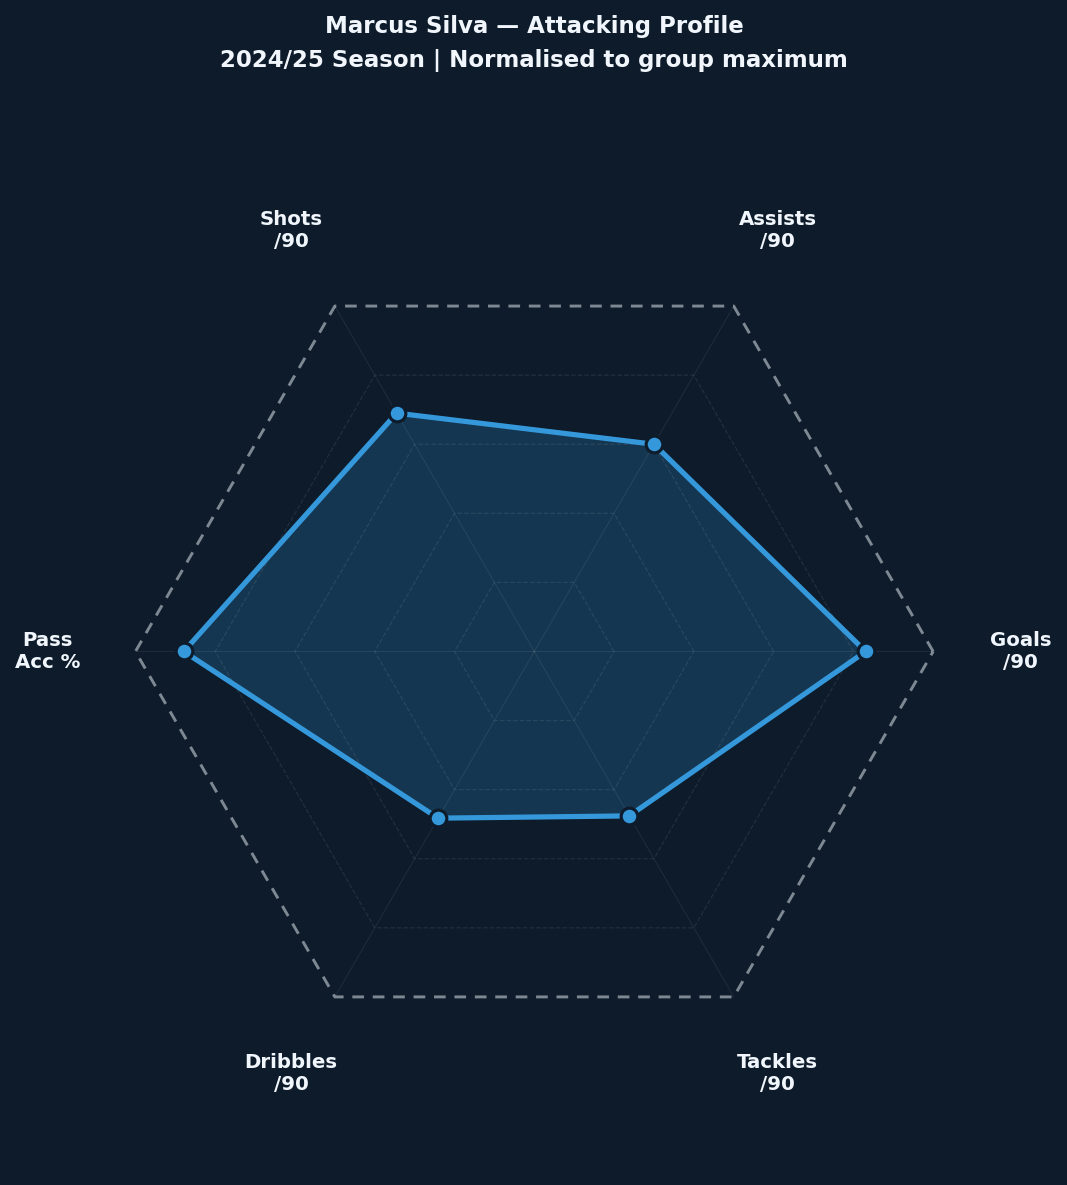

Normalised values (0-100 scale):
  Goals /90       raw=0.54  normalised=83.1
  Assists /90     raw=0.33  normalised=60.0
  Shots /90       raw=3.45  normalised=69.0
  Pass Acc %      raw=79.10  normalised=87.9
  Dribbles /90    raw=3.86  normalised=48.2
  Tackles /90     raw=1.19  normalised=47.6


In [1]:
# Single player radar — Marcus Silva
marcus = df[df['player'] == 'Marcus Silva'].iloc[0]

# Define the 6 metrics and their group maximums (for normalisation)
categories = ['Goals\n/90', 'Assists\n/90', 'Shots\n/90',
              'Pass\nAcc %', 'Dribbles\n/90', 'Tackles\n/90']

raw_values = [marcus['goals_per90'], marcus['assists_per90'],
              marcus['shots_per90'], marcus['pass_accuracy_pct'],
              marcus['dribbles_per90'], marcus['tackles_per90']]

# Normalise to 0-100 scale relative to group maximums
# This converts raw values to percentages of the "best in group"
group_maxes = [0.65, 0.55, 5.0, 90.0, 8.0, 2.5]
values = [min(v / m * 100, 100) for v, m in zip(raw_values, group_maxes)]

print("Normalised values (0-100 scale):")
for cat, raw, norm in zip(categories, raw_values, values):
    print(f"  {cat.replace(chr(10),' '):<15} raw={raw:.2f}  normalised={norm:.1f}")

# ── Radar geometry ────────────────────────────────────────────────────────
n = len(categories)
angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
angles_closed = angles + angles[:1]          # close the polygon
values_closed  = values + values[:1]          # close the polygon

# ── Draw the radar ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(BG2)
ax.set_facecolor(BG2)

# Interior grid rings (subtle dashed circles)
for level in [20, 40, 60, 80]:
    ax.plot(angles_closed, [level]*(n+1),
            color=WHITE, alpha=0.09, linewidth=0.6, linestyle='--')

# Outer boundary ring (dotted) — this is the 100th percentile
ax.plot(angles_closed, [100]*(n+1),
        color=WHITE, alpha=0.50, linewidth=1.4, linestyle=(0, (4, 3)))

# Spoke lines from centre to outer ring
for angle in angles:
    ax.plot([angle, angle], [0, 100],
            color=WHITE, alpha=0.08, linewidth=0.5)

# Player polygon — fill + line + vertex dots
c = PLAYER_COLORS['Marcus Silva']
ax.fill(angles_closed, values_closed, color=c, alpha=0.22)
ax.plot(angles_closed, values_closed, color=c, linewidth=2.5)
for angle, value in zip(angles, values):
    ax.plot(angle, value, 'o', color=c,
            markersize=8, markeredgecolor=BG2, markeredgewidth=1.5, zorder=5)

# Category labels
for angle, cat in zip(angles, categories):
    ax.text(angle, 122, cat,
            ha='center', va='center', fontsize=9.5,
            color=WHITE, fontweight='bold', multialignment='center')

# Clean up polar axes
ax.set_ylim(0, 130)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['polar'].set_visible(False)
ax.grid(False)

ax.set_title('Marcus Silva — Attacking Profile\n'
             '2024/25 Season | Normalised to group maximum',
             color=WHITE, fontsize=11, fontweight='bold', pad=32, linespacing=1.6)

plt.tight_layout()
plt.show()

---
## Part 3 — Dual Player Radar

Two players on the same axes. Each gets their own fill and line. The two polygons overlap — the area that one player has and the other doesn't is immediately visible.

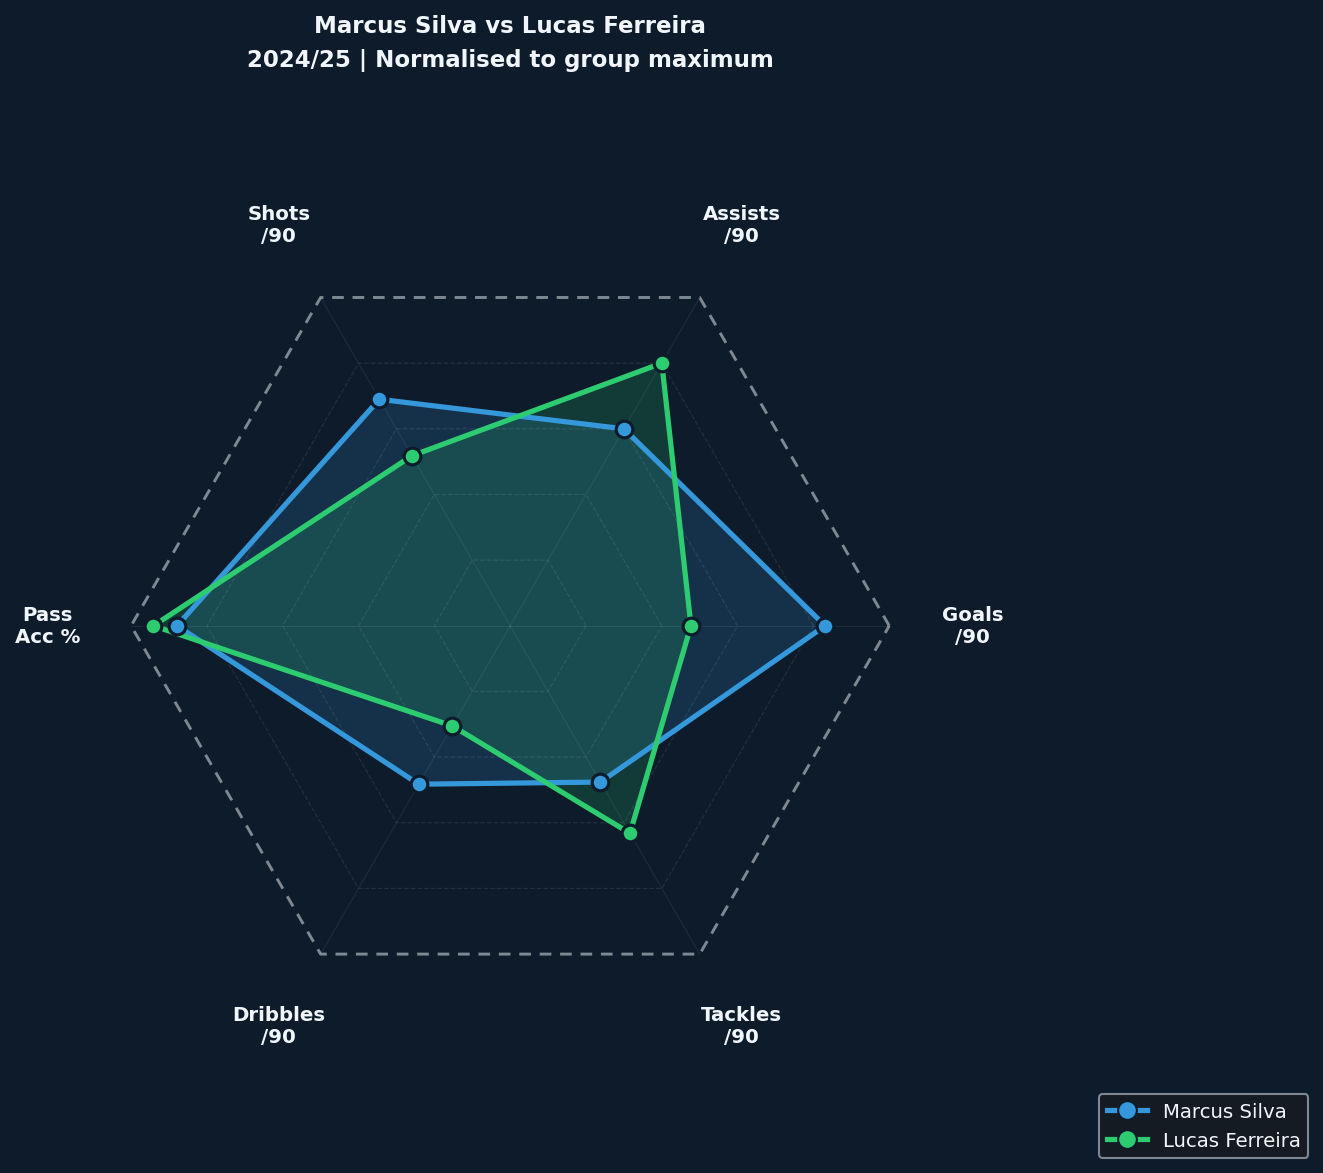

✓ build_radar() working.
  Change player1, player2, title — everything else is handled.


In [1]:
def build_radar(df, player1, player2=None,
               categories=None, group_maxes=None,
               title=None, figsize=(9, 9)):
    """
    Build a single or dual-player radar chart.

    Parameters
    ----------
    df           : DataFrame
    player1      : str — first (or only) player
    player2      : str — second player (optional, for dual radar)
    categories   : list[str] — metric labels (with \\n for line breaks)
    group_maxes  : list[float] — normalisation maximums for each metric
    title        : str — chart title (auto-generated if None)
    figsize      : tuple

    Returns: fig, ax

    Default metrics (if categories/maxes not provided):
        Goals/90, Assists/90, Shots/90, Pass Acc, Dribbles/90, Tackles/90
    """
    if categories is None:
        categories = ['Goals\n/90','Assists\n/90','Shots\n/90',
                      'Pass\nAcc %','Dribbles\n/90','Tackles\n/90']
    if group_maxes is None:
        group_maxes = [0.65, 0.55, 5.0, 90.0, 8.0, 2.5]

    metric_cols = ['goals_per90','assists_per90','shots_per90',
                   'pass_accuracy_pct','dribbles_per90','tackles_per90']

    def get_normalised(player):
        row = df[df['player'] == player].iloc[0]
        raw = [row[c] for c in metric_cols]
        return [min(v/m*100, 100) for v, m in zip(raw, group_maxes)]

    n = len(categories)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
    ac = angles + angles[:1]

    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(polar=True))
    fig.patch.set_facecolor(BG2); ax.set_facecolor(BG2)

    # Grid
    for lv in [20, 40, 60, 80]:
        ax.plot(ac, [lv]*(n+1), color=WHITE, alpha=0.09,
                linewidth=0.6, linestyle='--')
    ax.plot(ac, [100]*(n+1), color=WHITE, alpha=0.50,
            linewidth=1.4, linestyle=(0, (4, 3)))
    for a in angles:
        ax.plot([a, a], [0, 100], color=WHITE, alpha=0.08, linewidth=0.5)

    legend_handles = []
    for player in ([player1] + ([player2] if player2 else [])):
        vals = get_normalised(player)
        vc   = vals + vals[:1]
        c    = PLAYER_COLORS.get(player, GRAY)
        ax.fill(ac, vc, color=c, alpha=0.18)
        ax.plot(ac, vc, color=c, linewidth=2.5)
        for a, v in zip(angles, vals):
            ax.plot(a, v, 'o', color=c, markersize=8,
                    markeredgecolor=BG2, markeredgewidth=1.5, zorder=5)
        legend_handles.append(
            Line2D([0],[0], marker='o', color=c, label=player,
                   markerfacecolor=c, markeredgecolor=BG2,
                   markersize=9, linewidth=2.5))

    for a, cat in zip(angles, categories):
        ax.text(a, 122, cat, ha='center', va='center',
                fontsize=9.5, color=WHITE, fontweight='bold',
                multialignment='center')

    ax.set_ylim(0, 130); ax.set_yticks([]); ax.set_xticks([])
    ax.spines['polar'].set_visible(False); ax.grid(False)

    if player2:
        ax.legend(handles=legend_handles, loc='lower right',
                  bbox_to_anchor=(1.32, -0.05), fontsize=9.5,
                  facecolor=BG3, edgecolor=GRAY,
                  labelcolor=WHITE, framealpha=0.9)

    chart_title = title or (f'{player1} vs {player2}' if player2 else player1)
    ax.set_title(chart_title + '\n2024/25 | Normalised to group maximum',
                 color=WHITE, fontsize=11, fontweight='bold',
                 pad=32, linespacing=1.6)

    plt.tight_layout()
    return fig, ax

# Test — dual radar
fig, ax = build_radar(df, 'Marcus Silva', 'Lucas Ferreira',
                      title='Finisher vs Creator — Radar Comparison')
plt.show()
print("✓ build_radar() working.")
print("  Change player1, player2, title — everything else is handled.")

### What the Dual Radar Shows

**Marcus Silva** (blue) dominates on Goals, Shots, and Dribbles — the areas
that make him dangerous as an individual attacker.

**Lucas Ferreira** (green) extends further on Assists, Pass Accuracy, and is
comparable on Tackles — the areas that make him valuable as a team player.

The overlapping area shows where they are similar. The non-overlapping area
shows where each player is uniquely better. In a 3-second glance, you have
the complete comparative profile.

---
## Exercises

### Exercise 1 (Easy) — Change the Players
Call `build_radar(df, 'Diego Varela', 'James Thornton')`. Which metrics does
the younger Thornton already beat the experienced Varela on?

### Exercise 2 (Medium) — Change the Metrics
Modify `build_radar()` to use different metrics:
`xg_per90, xa_per90, sot_per90, keyp_per90, dribbles_per90, tackles_per90`.
Update `group_maxes` to appropriate values for each.

### Exercise 3 (Hard) — Add Percentile Labels
For each vertex dot, add a text label showing the normalised value (e.g., "82"):
```python
for a, v in zip(angles, vals):
    ax.text(a, v+5, f'{v:.0f}', ha='center', va='bottom', color=c, fontsize=7.5)
```
This shows the exact percentile score at each vertex without needing to look at the data table.

---
## Chapter Summary

| Concept | What You Learned |
|---------|-----------------|
| Polar coordinates | `subplot_kw=dict(polar=True)` |
| Closing the polygon | `angles + angles[:1]` and `values + values[:1]` |
| Normalisation | Convert raw to 0-100 using group maximums |
| Grid rings | `ax.plot()` at each level — 20, 40, 60, 80, 100 |
| Outer boundary | Dotted ring at 100 — the reference maximum |
| Vertex markers | `ax.plot(a, v, 'o')` at each metric point |
| `build_radar()` | Template — any two players, any 6 metrics |

---
## Up Next — Chapter 8: Pizza Charts

*© 2026 HackrLife Media LLC · BarcaFutbol Analytics Course*